# **Required libraries**

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

# **Verify GPU availability**

In [2]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Dataset Download**


In [5]:
# Upload kaggle.json first (API token from Kaggle account)
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d emmarex/plantdisease
!unzip plantdisease.zip -d ./plantvillage

Streaming output truncated to the last 5000 lines.
  inflating: ./plantvillage/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: ./plantvillage/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: ./plantvillage/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: ./plantvillage/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: ./plantvillage/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: ./plantvillage/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: 

In [6]:
base_dir = './plantvillage/PlantVillage'
classes = os.listdir(base_dir)
print(f"Total classes: {len(classes)}")
print(f"Classes: {classes}")

Total classes: 15
Classes: ['Tomato_Bacterial_spot', 'Potato___Late_blight', 'Pepper__bell___Bacterial_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_healthy', 'Pepper__bell___healthy', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Leaf_Mold']


In [7]:
# Use Keras ImageDataGenerator with validation_split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,      # 15% validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Training: 70%, Validation: 15%, Test: 15%
# We'll hold out test set separately or use validation_split twice

# **Data Preprocessing**

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import shutil

# Paths
base_dir = './plantvillage/PlantVillage'
img_size = 224
batch_size = 32

# Create train/val/test directories
def prepare_splits(base_dir, train_dir, val_dir, test_dir, split_ratio=(0.7, 0.15, 0.15)):
    classes = os.listdir(base_dir)

    for split_dir in [train_dir, val_dir, test_dir]:
        os.makedirs(split_dir, exist_ok=True)

    for cls in classes:
        cls_path = os.path.join(base_dir, cls)
        images = os.listdir(cls_path)

        train_imgs, temp_imgs = train_test_split(images, test_size=(1-split_ratio[0]), random_state=42)
        val_imgs, test_imgs = train_test_split(temp_imgs, test_size=(split_ratio[2]/(split_ratio[1]+split_ratio[2])), random_state=42)

        for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
            dst_dir = os.path.join({'train': train_dir, 'val': val_dir, 'test': test_dir}[split_name], cls)
            os.makedirs(dst_dir, exist_ok=True)
            for img in split_imgs:
                shutil.copy(os.path.join(cls_path, img), os.path.join(dst_dir, img))

    return classes

train_dir = './data/train'
val_dir = './data/val'
test_dir = './data/test'

classes = prepare_splits(base_dir, train_dir, val_dir, test_dir)
print(f"Classes: {classes}")
print(f"Total classes: {len(classes)}")

Classes: ['Tomato_Bacterial_spot', 'Potato___Late_blight', 'Pepper__bell___Bacterial_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_healthy', 'Pepper__bell___healthy', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Leaf_Mold']
Total classes: 15


# **Data Augmentation**

In [9]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# Training: with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation/Test: only preprocessing
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 14438 images belonging to 15 classes.
Found 3097 images belonging to 15 classes.
Found 3103 images belonging to 15 classes.
Training samples: 14438
Validation samples: 3097
Test samples: 3103


# **Build Feature Extractor**

In [10]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load EfficientNet-B0 without top layers
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

# Freeze all layers
base_model.trainable = False

# Add global pooling to get feature vectors
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

print(f"Feature vector dimension: {feature_extractor.output_shape[-1]}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature vector dimension: 1280


# **Extract Features**

In [11]:
def extract_features(generator, model):
    features = []
    labels = []

    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat_batch = model.predict(x_batch, verbose=0)
        features.extend(feat_batch)
        labels.extend(y_batch)

        if (i + 1) % 50 == 0:
            print(f"Processed {(i+1)*batch_size} images")

    return np.array(features), np.array(labels)

print("Extracting training features...")
start_time = time.time()
train_features, train_labels = extract_features(train_generator, feature_extractor)
print(f"Training extraction time: {time.time() - start_time:.2f}s")

print("Extracting validation features...")
val_features, val_labels = extract_features(val_generator, feature_extractor)

print("Extracting test features...")
test_features, test_labels = extract_features(test_generator, feature_extractor)

# Convert one-hot to class indices
train_labels_idx = np.argmax(train_labels, axis=1)
val_labels_idx = np.argmax(val_labels, axis=1)
test_labels_idx = np.argmax(test_labels, axis=1)

print(f"Feature shape: {train_features.shape}")

Extracting training features...
Processed 1600 images
Processed 3200 images
Processed 4800 images
Processed 6400 images
Processed 8000 images
Processed 9600 images
Processed 11200 images
Processed 12800 images
Processed 14400 images
Training extraction time: 268.31s
Extracting validation features...
Processed 1600 images
Extracting test features...
Processed 1600 images
Feature shape: (14438, 1280)


# **Train Logistic Regression**

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Scale features (important for logistic regression)
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
val_features_scaled = scaler.transform(val_features)
test_features_scaled = scaler.transform(test_features)

# Train Logistic Regression
print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    C=1.0,  # Regularization strength
    random_state=42,
    n_jobs=-1
)

lr_model.fit(train_features_scaled, train_labels_idx)
lr_train_time = time.time() - start_time
print(f"LR Training time: {lr_train_time:.2f}s")

# Predictions
lr_pred = lr_model.predict(test_features_scaled)
lr_pred_proba = lr_model.predict_proba(test_features_scaled)

# Metrics
lr_accuracy = accuracy_score(test_labels_idx, lr_pred)
lr_precision = precision_score(test_labels_idx, lr_pred, average='weighted')
lr_recall = recall_score(test_labels_idx, lr_pred, average='weighted')
lr_f1 = f1_score(test_labels_idx, lr_pred, average='weighted')

print(f"\nApproach 1 - Logistic Regression Results:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LR Training time: 6.14s

Approach 1 - Logistic Regression Results:
Accuracy:  0.9065
Precision: 0.9228
Recall:    0.9065
F1-Score:  0.9096


# **End-to-End EfficientNet-B0**

In [13]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load base model (frozen initially)
base_model_full = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

# Freeze base layers for initial training
base_model_full.trainable = False

# Add custom classification head
x = base_model_full.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(15, activation='softmax')(x)

end_to_end_model = Model(inputs=base_model_full.input, outputs=predictions)

end_to_end_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,720,306 (18.01 MB)

 Trainable params: 667,151 (2.54 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

In [14]:
# Compile
end_to_end_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('best_model_phase1.h5', monitor='val_accuracy', save_best_only=True)
]

print("Phase 1: Training top layers only...")
start_time = time.time()

history_phase1 = end_to_end_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

phase1_time = time.time() - start_time
print(f"Phase 1 training time: {phase1_time:.2f}s")

Phase 1: Training top layers only...
Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.6151 - loss: 1.3585

452/452 ━━━━━━━━━━━━━━━━━━━━ 251s 502ms/step - accuracy: 0.7187 - loss: 0.9336 - val_accuracy: 0.8673 - val_loss: 0.3975 - learning_rate: 0.0010
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8084 - loss: 0.5776

452/452 ━━━━━━━━━━━━━━━━━━━━ 198s 438ms/step - accuracy: 0.8151 - loss: 0.5600 - val_accuracy: 0.8860 - val_loss: 0.3480 - learning_rate: 0.0010
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8352 - loss: 0.5043

452/452 ━━━━━━━━━━━━━━━━━━━━ 196s 433ms/step - accuracy: 0.8387 - loss: 0.4916 - val_accuracy: 0.8905 - val_loss: 0.3111 - learning_rate: 0.0010
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8513 - loss: 0.4567

452/452 ━━━━━━━━━━━━━━━━━━━━ 194s 429ms/step - accuracy: 0.8485 - loss: 0.4575 - val_accuracy: 0.9064 - val_loss: 0.2767 - learning_rate: 0.0010
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8545 - loss: 0.4317

452/452 ━━━━━━━━━━━━━━━━━━━━ 198s 439ms/step - accuracy: 0.8581 - loss: 0.4217 - val_accuracy: 0.9228 - val_loss: 0.2320 - learning_rate: 0.0010
Epoch 6/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8643 - loss: 0.3947

452/452 ━━━━━━━━━━━━━━━━━━━━ 211s 466ms/step - accuracy: 0.8634 - loss: 0.4086 - val_accuracy: 0.9264 - val_loss: 0.2288 - learning_rate: 0.0010
Epoch 7/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 221s 487ms/step - accuracy: 0.8649 - loss: 0.4037 - val_accuracy: 0.9164 - val_loss: 0.2390 - learning_rate: 0.0010
Epoch 8/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 228s 505ms/step - accuracy: 0.8676 - loss: 0.3941 - val_accuracy: 0.9202 - val_loss: 0.2244 - learning_rate: 0.0010
Epoch 9/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 224s 495ms/step - accuracy: 0.8740 - loss: 0.3794 - val_accuracy: 0.9202 - val_loss: 0.2409 - learning_rate: 0.0010
Epoch 10/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8752 - loss: 0.3662

452/452 ━━━━━━━━━━━━━━━━━━━━ 216s 478ms/step - accuracy: 0.8746 - loss: 0.3678 - val_accuracy: 0.9364 - val_loss: 0.2044 - learning_rate: 0.0010
Epoch 11/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 215s 476ms/step - accuracy: 0.8757 - loss: 0.3673 - val_accuracy: 0.9309 - val_loss: 0.2051 - learning_rate: 0.0010
Epoch 12/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 218s 482ms/step - accuracy: 0.8794 - loss: 0.3584 - val_accuracy: 0.9354 - val_loss: 0.2055 - learning_rate: 0.0010
Epoch 13/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 224s 494ms/step - accuracy: 0.8852 - loss: 0.3427 - val_accuracy: 0.9241 - val_loss: 0.2164 - learning_rate: 0.0010
Epoch 14/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 226s 500ms/step - accuracy: 0.8891 - loss: 0.3303 - val_accuracy: 0.9351 - val_loss: 0.1973 - learning_rate: 5.0000e-04
Epoch 15/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 222s 492ms/step - accuracy: 0.8965 - loss: 0.3091 - val_accuracy: 0.9190 - val_loss: 0.2228 - learning_rate: 5.0000e-04
Epoch 16/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 208s 460ms/step - acc

452/452 ━━━━━━━━━━━━━━━━━━━━ 207s 459ms/step - accuracy: 0.8982 - loss: 0.2989 - val_accuracy: 0.9403 - val_loss: 0.1793 - learning_rate: 5.0000e-04
Epoch 18/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 206s 456ms/step - accuracy: 0.9024 - loss: 0.2963 - val_accuracy: 0.9396 - val_loss: 0.1816 - learning_rate: 5.0000e-04
Epoch 19/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 203s 449ms/step - accuracy: 0.9048 - loss: 0.2849 - val_accuracy: 0.9387 - val_loss: 0.1839 - learning_rate: 5.0000e-04
Epoch 20/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 198s 438ms/step - accuracy: 0.9044 - loss: 0.2761 - val_accuracy: 0.9341 - val_loss: 0.1882 - learning_rate: 5.0000e-04
Phase 1 training time: 4264.81s


In [15]:
# Unfreeze base model for fine-tuning
base_model_full.trainable = True

# Fine-tune from block 6 onwards (last ~20% of layers) to prevent overfitting
# Or unfreeze all if you have GPU time
for layer in base_model_full.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
end_to_end_model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 10-100x smaller than Phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-9),
    ModelCheckpoint('best_model_phase2.h5', monitor='val_accuracy', save_best_only=True)
]

print("Phase 2: Fine-tuning with lower learning rate...")
start_time = time.time()

history_phase2 = end_to_end_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks_phase2,
    verbose=1
)

phase2_time = time.time() - start_time
total_dl_time = phase1_time + phase2_time
print(f"Phase 2 training time: {phase2_time:.2f}s")
print(f"Total DL training time: {total_dl_time:.2f}s")

Phase 2: Fine-tuning with lower learning rate...
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.7920 - loss: 0.6461

452/452 ━━━━━━━━━━━━━━━━━━━━ 279s 525ms/step - accuracy: 0.8039 - loss: 0.6035 - val_accuracy: 0.9173 - val_loss: 0.2344 - learning_rate: 1.0000e-05
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8342 - loss: 0.4933

452/452 ━━━━━━━━━━━━━━━━━━━━ 204s 452ms/step - accuracy: 0.8417 - loss: 0.4716 - val_accuracy: 0.9219 - val_loss: 0.2119 - learning_rate: 1.0000e-05
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8643 - loss: 0.4033

452/452 ━━━━━━━━━━━━━━━━━━━━ 226s 500ms/step - accuracy: 0.8651 - loss: 0.4028 - val_accuracy: 0.9293 - val_loss: 0.1951 - learning_rate: 1.0000e-05
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8761 - loss: 0.3794

452/452 ━━━━━━━━━━━━━━━━━━━━ 232s 513ms/step - accuracy: 0.8731 - loss: 0.3783 - val_accuracy: 0.9351 - val_loss: 0.1823 - learning_rate: 1.0000e-05
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.8868 - loss: 0.3415

...

452/452 ━━━━━━━━━━━━━━━━━━━━ 234s 519ms/step - accuracy: 0.8920 - loss: 0.3187 - val_accuracy: 0.9419 - val_loss: 0.1681 - learning_rate: 1.0000e-05
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8958 - loss: 0.3139

452/452 ━━━━━━━━━━━━━━━━━━━━ 234s 517ms/step - accuracy: 0.8967 - loss: 0.3095 - val_accuracy: 0.9438 - val_loss: 0.1631 - learning_rate: 1.0000e-05
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9001 - loss: 0.2935

452/452 ━━━━━━━━━━━━━━━━━━━━ 233s 515ms/step - accuracy: 0.9003 - loss: 0.2910 - val_accuracy: 0.9441 - val_loss: 0.1555 - learning_rate: 1.0000e-05
Epoch 9/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.8993 - loss: 0.2897

452/452 ━━━━━━━━━━━━━━━━━━━━ 233s 515ms/step - accuracy: 0.9005 - loss: 0.2855 - val_accuracy: 0.9474 - val_loss: 0.1444 - learning_rate: 1.0000e-05
Epoch 10/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9108 - loss: 0.2691

452/452 ━━━━━━━━━━━━━━━━━━━━ 234s 517ms/step - accuracy: 0.9078 - loss: 0.2726 - val_accuracy: 0.9490 - val_loss: 0.1392 - learning_rate: 1.0000e-05
Phase 2 training time: 2340.82s
Total DL training time: 6605.63s


In [17]:
from sklearn.metrics import classification_report

# Load best weights
end_to_end_model.load_weights('best_model_phase2.h5')

# Evaluate on test set
print("Evaluating End-to-End model on test set...")
dl_loss, dl_accuracy = end_to_end_model.evaluate(test_generator, verbose=1)

# Get predictions for detailed metrics
test_generator.reset()
dl_pred_proba = end_to_end_model.predict(test_generator, verbose=1)
dl_pred = np.argmax(dl_pred_proba, axis=1)
test_labels_reset = test_generator.classes  # Original labels

# Metrics
dl_precision = precision_score(test_labels_reset, dl_pred, average='weighted')
dl_recall = recall_score(test_labels_reset, dl_pred, average='weighted')
dl_f1 = f1_score(test_labels_reset, dl_pred, average='weighted')

print(f"\nApproach 2 - End-to-End DL Results:")
print(f"Accuracy:  {dl_accuracy:.4f}")
print(f"Precision: {dl_precision:.4f}")
print(f"Recall:    {dl_recall:.4f}")
print(f"F1-Score:  {dl_f1:.4f}")

Evaluating End-to-End model on test set...
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9613 - loss: 0.1294
97/97 ━━━━━━━━━━━━━━━━━━━━ 19s 125ms/step

Approach 2 - End-to-End DL Results:
Accuracy:  0.9613
Precision: 0.9628
Recall:    0.9613
F1-Score:  0.9615


# **End-to-End ResNet50**

In [16]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50
base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

# Freeze initially
base_resnet.trainable = False

# Build head
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
resnet_predictions = Dense(15, activation='softmax')(x)

resnet_model = Model(inputs=base_resnet.input, outputs=resnet_predictions)

# Phase 1: Train head
resnet_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

print("Training ResNet50 Phase 1...")
resnet_history1 = resnet_model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

# Phase 2: Fine-tune
base_resnet.trainable = True
for layer in base_resnet.layers[:-30]:  # Freeze earlier layers
    layer.trainable = False

resnet_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print("Fine-tuning ResNet50...")
resnet_history2 = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[EarlyStopping(patience=7, restore_best_weights=True)],
    verbose=1
)

# Evaluate
resnet_loss, resnet_acc = resnet_model.evaluate(test_generator, verbose=1)
print(f"ResNet50 Test Accuracy: {resnet_acc:.4f}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training ResNet50 Phase 1...
Epoch 1/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 273s 569ms/step - accuracy: 0.7231 - loss: 0.8644 - val_accuracy: 0.8586 - val_loss: 0.4402
Epoch 2/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 245s 542ms/step - accuracy: 0.8262 - loss: 0.5074 - val_accuracy: 0.8689 - val_loss: 0.3781
Epoch 3/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 247s 546ms/step - accuracy: 0.8541 - loss: 0.4214 - val_accuracy: 0.9012 - val_loss: 0.2950
Epoch 4/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 247s 547ms/step - accuracy: 0.8698 - loss: 0.3826 - val_accuracy: 0.9064 - val_loss: 0.2839
Epoch 5/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 259s 540ms/step - accuracy: 0.8771 - loss: 0.3576 - val_accuracy: 0.9138 - val_loss: 0.2511
Epoch 6/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 242s 535ms/step - accuracy: 0.8881 - loss: 0.3260 - val_accuracy: 0.8983 - val_loss: 0.2980
Epoch 7/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 238s 527ms/step - accuracy: 0.8888 - loss: 0.3295 - val_accuracy: 0.9267 - val_loss: 0.2250
Epo

# **Comparative Analysis & Visualizations**

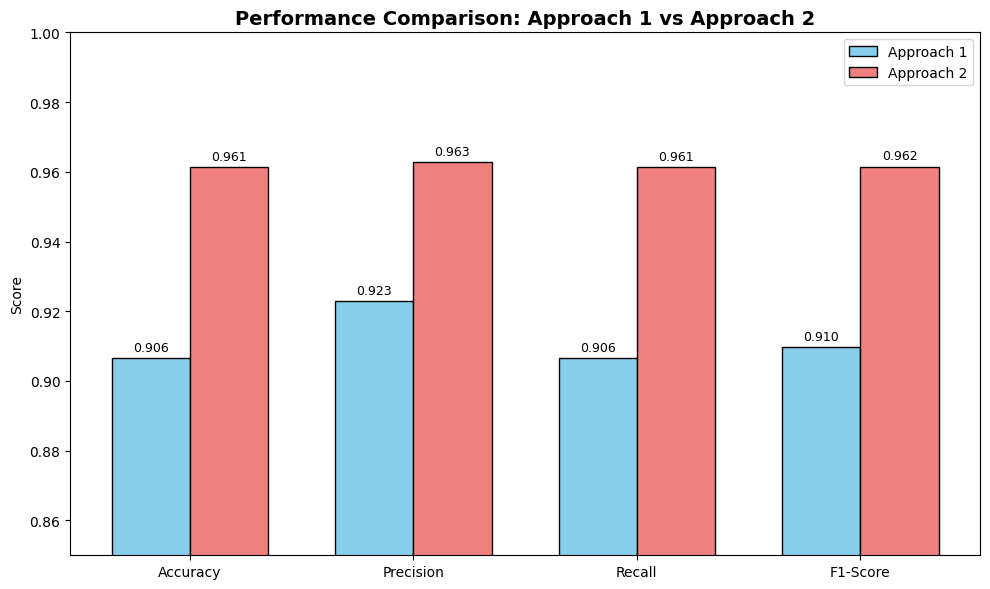

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Data
approaches = ['Approach 1\n(Feature Extractor + LR)', 'Approach 2\n(End-to-End EfficientNet-B0)']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
approach1_scores = [0.9065, 0.9228, 0.9065, 0.9096]
approach2_scores = [0.9613, 0.9628, 0.9613, 0.9615]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, approach1_scores, width, label='Approach 1', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, approach2_scores, width, label='Approach 2', color='lightcoral', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Approach 1 vs Approach 2', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0.85, 1.0)

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/Results/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

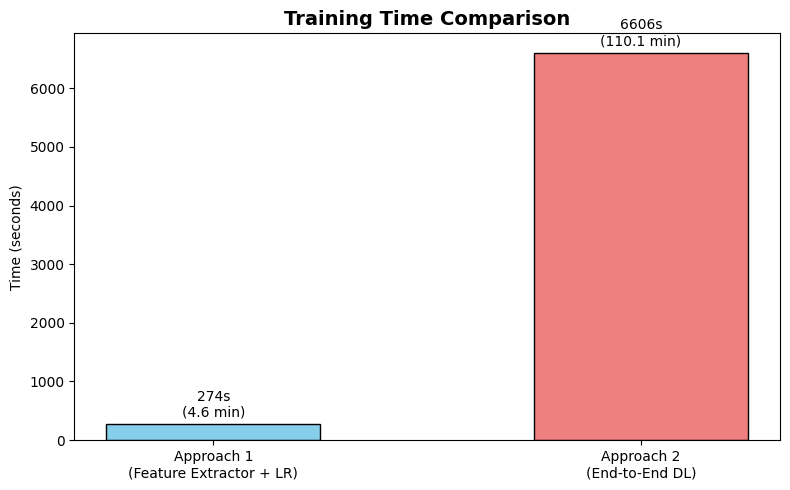

In [22]:
# Training time comparison
fig, ax = plt.subplots(figsize=(8, 5))
approaches_time = ['Approach 1\n(Feature Extractor + LR)', 'Approach 2\n(End-to-End DL)']
times = [274.45, 6605.63]
colors = ['skyblue', 'lightcoral']

bars = ax.bar(approaches_time, times, color=colors, edgecolor='black', width=0.5)
ax.set_ylabel('Time (seconds)')
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}s\n({height/60:.1f} min)',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/content/Results/training_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

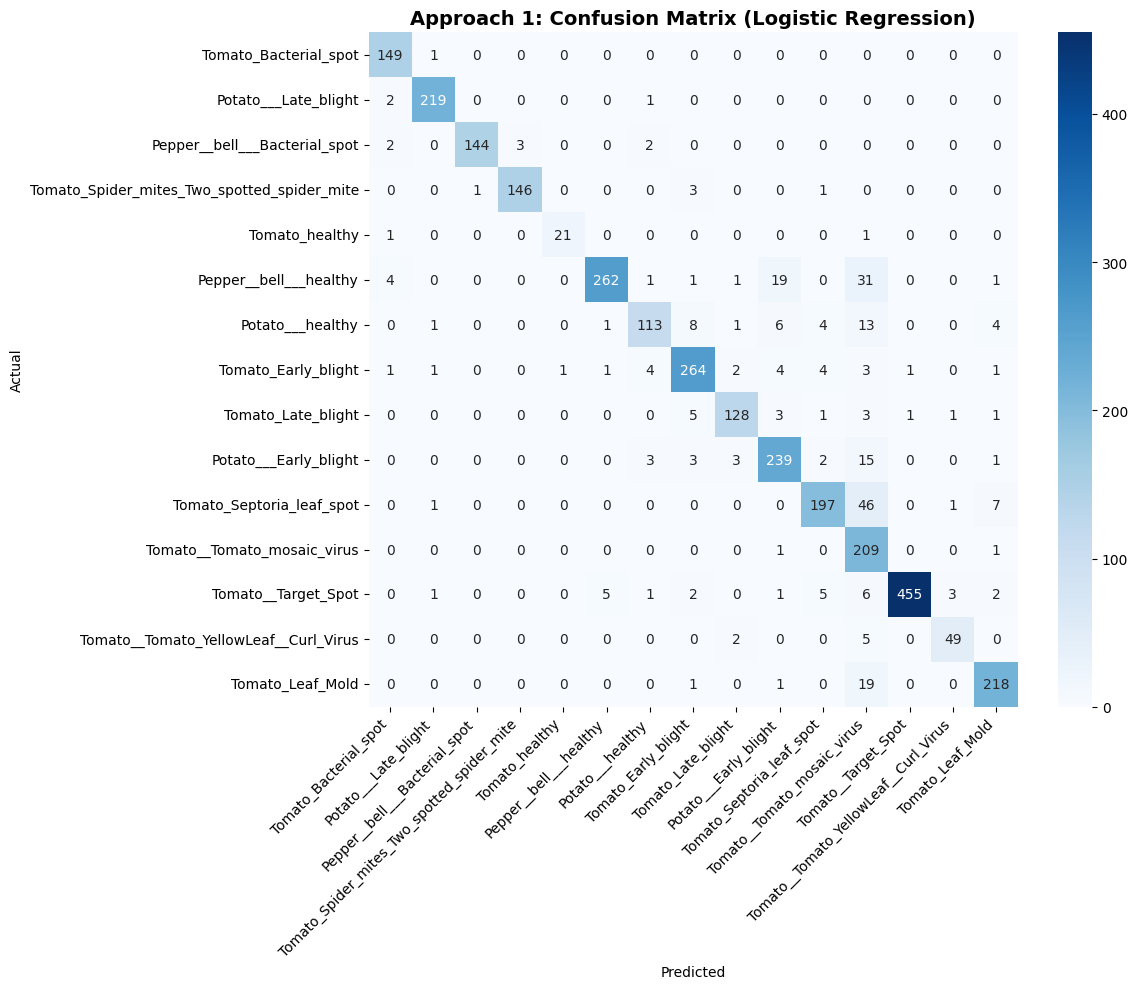

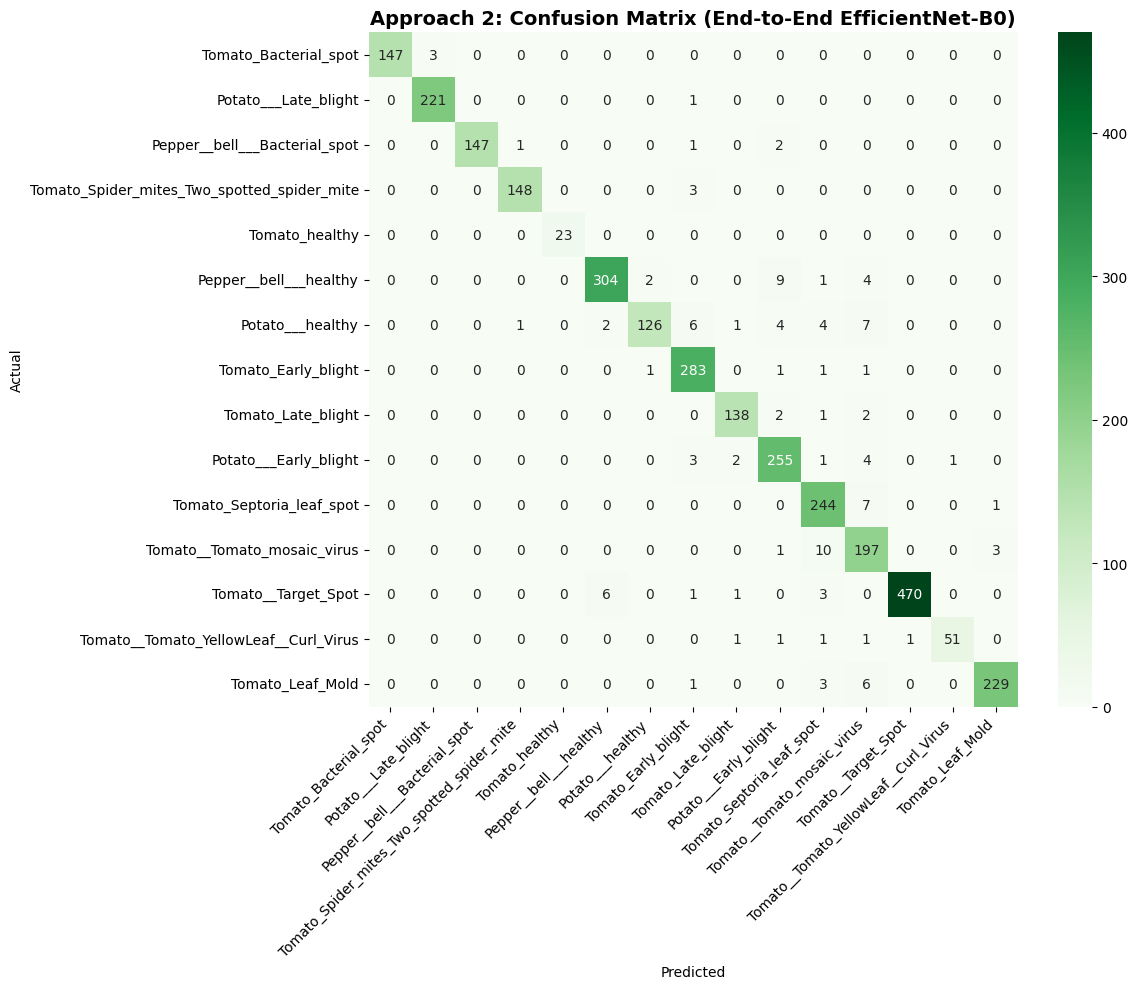

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Approach 1 Confusion Matrix
cm_lr = confusion_matrix(test_labels_idx, lr_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Approach 1: Confusion Matrix (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/Results/confusion_matrix_approach1.png', dpi=300, bbox_inches='tight')
plt.show()

# Approach 2 Confusion Matrix
cm_dl = confusion_matrix(test_labels_reset, dl_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('Approach 2: Confusion Matrix (End-to-End EfficientNet-B0)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/Results/confusion_matrix_approach2.png', dpi=300, bbox_inches='tight')
plt.show()

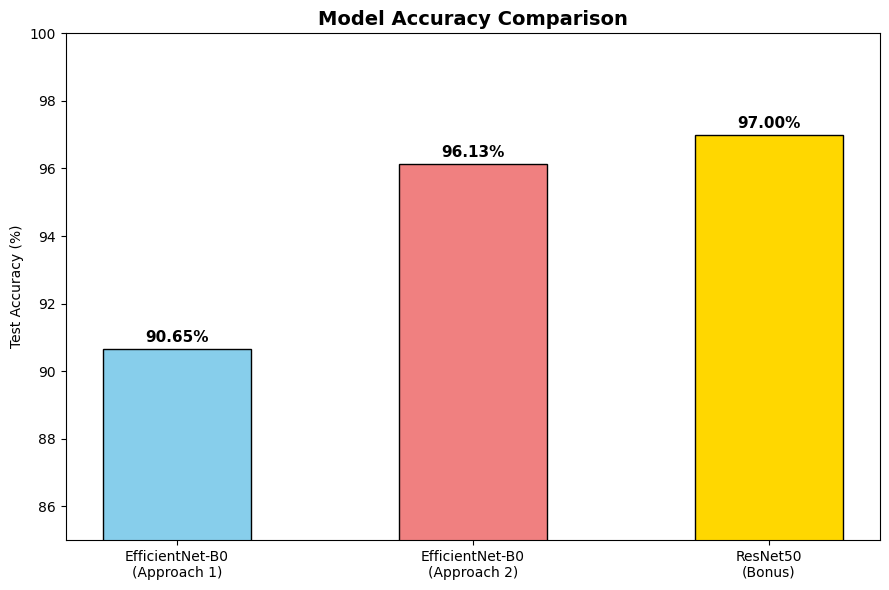

In [24]:
# Accuracy comparison including bonus
models = ['EfficientNet-B0\n(Approach 1)', 'EfficientNet-B0\n(Approach 2)', 'ResNet50\n(Bonus)']
accuracies = [90.65, 96.13, 97.00]
colors = ['skyblue', 'lightcoral', 'gold']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(85, 100)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/Results/model_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

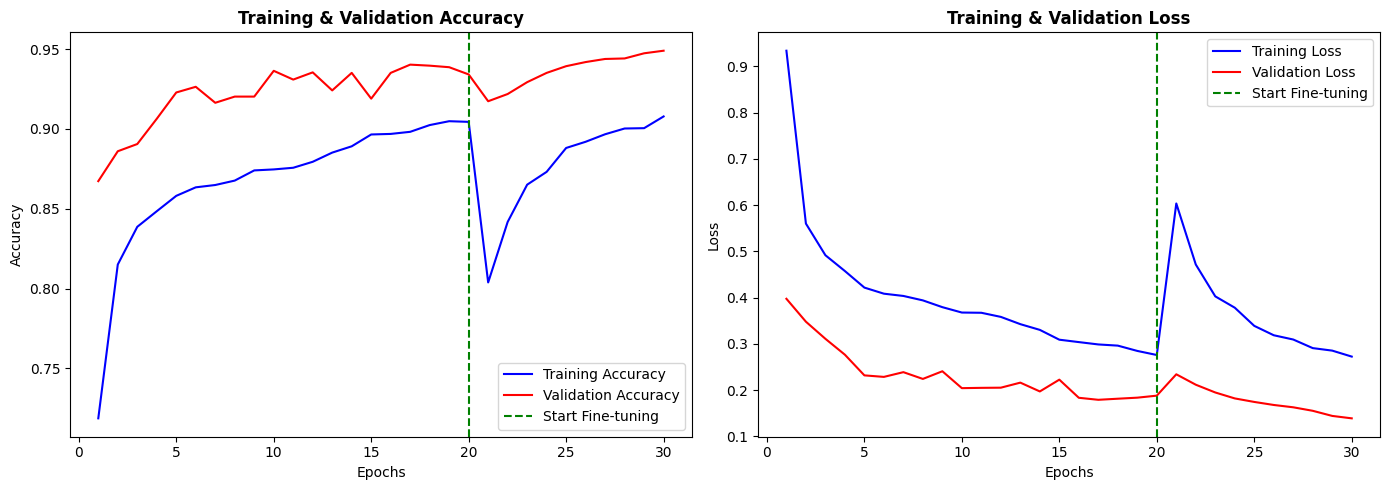

In [25]:
# Combine phase 1 and phase 2 history
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

epochs = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs, acc, 'b-', label='Training Accuracy')
ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
ax1.axvline(x=len(history_phase1.history['accuracy']), color='g', linestyle='--', label='Start Fine-tuning')
ax1.set_title('Training & Validation Accuracy', fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss
ax2.plot(epochs, loss, 'b-', label='Training Loss')
ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')
ax2.axvline(x=len(history_phase1.history['loss']), color='g', linestyle='--', label='Start Fine-tuning')
ax2.set_title('Training & Validation Loss', fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/Results/learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# **Extra Dataset (CIFAR-10)**

In [11]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

# ============================================
# 1. Download Chest X-Ray Dataset
# ============================================
# Option A: Kaggle API (if you have kaggle.json)
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip chest-xray-pneumonia.zip -d ./chest_xray

# Option B: Direct download (faster)
#!wget -q https://storage.googleapis.com/kaggle-data-sets/17810/23812/bundle/archive.zip?X-Goog-Algorithm=GOOG4-RSA-SHA256 -O chest_xray.zip
#!unzip -q chest_xray.zip -d ./chest_xray || echo "Using manual download..."

# ============================================
# 2. Setup Paths
# ============================================
chest_dir = './chest_xray/chest_xray'  # or wherever it extracts
train_dir = os.path.join(chest_dir, 'train')
test_dir = os.path.join(chest_dir, 'test')

# Check structure
print("Classes:", os.listdir(train_dir))
print("Train samples:", sum([len(os.listdir(os.path.join(train_dir, c))) for c in os.listdir(train_dir)]))
print("Test samples:", sum([len(os.listdir(os.path.join(test_dir, c))) for c in os.listdir(test_dir)]))

Streaming output truncated to the last 5000 lines.
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: ./chest_xray/chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating: ./chest_xra

In [13]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

# ============================================
# 1. SETUP PATHS (adjust these to your actual folder structure)
# ============================================
# Check what was extracted from your zip
import glob
possible_paths = [
    './chest_xray/chest_xray',
    './chest_xray',
    './chest_xray_v2',
    '/content/chest_xray',
    '/content/chest_xray/chest_xray'
]

chest_dir = None
for p in possible_paths:
    if os.path.exists(p):
        print(f"Found: {p}")
        print(f"Contents: {os.listdir(p)[:5]}")
        chest_dir = p
        break

if chest_dir is None:
    # Search for any folder containing 'train' and 'test'
    for root, dirs, files in os.walk('.'):
        if 'train' in dirs and 'test' in dirs:
            chest_dir = root
            print(f"Auto-found: {chest_dir}")
            break

if chest_dir is None:
    raise FileNotFoundError("Cannot find chest_xray dataset. Check your extracted folder.")

train_dir = os.path.join(chest_dir, 'train')
test_dir = os.path.join(chest_dir, 'test')

print(f"\nUsing train_dir: {train_dir}")
print(f"Classes: {os.listdir(train_dir)}")
print(f"Train samples: {sum([len(os.listdir(os.path.join(train_dir, c))) for c in os.listdir(train_dir)])}")
print(f"Test samples: {sum([len(os.listdir(os.path.join(test_dir, c))) for c in os.listdir(test_dir)])}")

# ============================================
# 2. CREATE DATA GENERATORS
# ============================================
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# ============================================
# 3. BUILD FEATURE EXTRACTOR
# ============================================
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# ============================================
# 4. EXTRACT FEATURES
# ============================================
def extract_features(generator, model):
    features, labels = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = model.predict(x_batch, verbose=0)
        features.extend(feat)
        labels.extend(y_batch)
        if (i + 1) % 50 == 0:
            print(f"Processed {(i+1)*batch_size}/{generator.samples} images")
    return np.array(features), np.array(labels)

print("\nExtracting training features...")
start = time.time()
train_feat, train_lab = extract_features(train_gen, feature_extractor)
print(f"Training extraction: {time.time()-start:.1f}s | Shape: {train_feat.shape}")

print("\nExtracting test features...")
start = time.time()
test_feat, test_lab = extract_features(test_gen, feature_extractor)
print(f"Test extraction: {time.time()-start:.1f}s | Shape: {test_feat.shape}")

# ============================================
# 5. TRAIN LOGISTIC REGRESSION
# ============================================
scaler = StandardScaler()
train_feat_s = scaler.fit_transform(train_feat)
test_feat_s = scaler.transform(test_feat)

print("\nTraining Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=1000, n_jobs=-1)
lr.fit(train_feat_s, train_lab)
lr_time = time.time() - start
print(f"LR training time: {lr_time:.2f}s")

# ============================================
# 6. EVALUATE
# ============================================
preds = lr.predict(test_feat_s)

acc = accuracy_score(test_lab, preds)
prec = precision_score(test_lab, preds)
rec = recall_score(test_lab, preds)
f1 = f1_score(test_lab, preds)

print(f"\n{'='*60}")
print(f"CHEST X-RAY RESULTS (Approach 1 - Feature Extractor + LR)")
print(f"{'='*60}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(test_lab, preds)}")

Found: ./chest_xray/chest_xray
Contents: ['__MACOSX', 'chest_xray', 'train', 'val', 'test']

Using train_dir: ./chest_xray/chest_xray/train
Classes: ['PNEUMONIA', 'NORMAL']
Train samples: 5216
Test samples: 624
Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Extracting training features...
Processed 1600/5216 images
Processed 3200/5216 images
Processed 4800/5216 images
Training extraction: 161.6s | Shape: (5216, 1280)

Extracting test features...
Test extraction: 23.7s | Shape: (624, 1280)

Training Logistic Regression...
LR training time: 3.46s

CHEST X-RAY RESULTS (Approach 1 - Feature Extractor + LR)
Accuracy:  0.8221
Precision: 0.7853
Recall:    0.9846
F1-Score:  0.8737
Confusion Matrix:
[[129 105]
 [  6 384]]
